<a href="https://colab.research.google.com/github/Shubhi87/API/blob/master/Copy_of_Production_RAG_HandsOn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠️ Production RAG — Hands-On Lab
## Building the *Enterprise DevOps & Support Agent*

This is a **single, runnable practical session** that takes **one use case** — the
**Enterprise DevOps & Support Agent** from the lecture, and shows how **every topic is used in a real production pipeline.

**Our use case (one agent, three knowledge sources):**
- 🧑‍💼 **HR / Policy** docs (leave, benefits, salary bands) — *some are confidential*
- 💻 **Codebase / Runbooks** (auth module, Kubernetes, CI/CD, payments)
- 📟 **Live Logs** (a simulated real-time monitoring API)


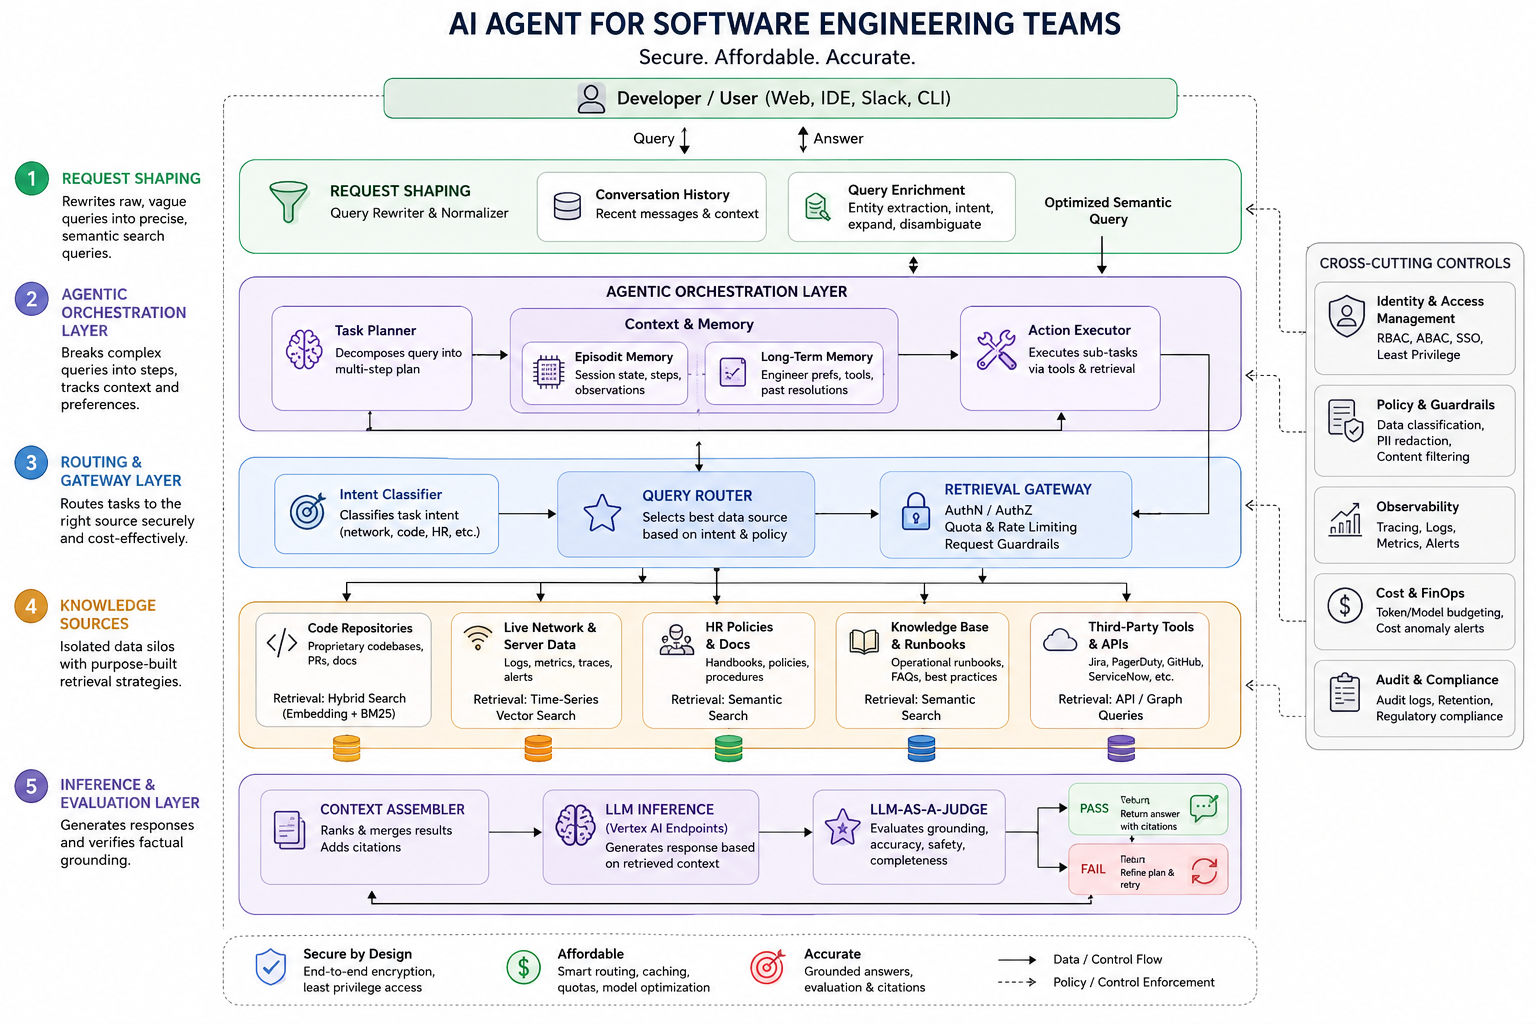
### ⚙️ Resource notes
We deliberately use **small, free models** so this runs on **CPU** (no GPU needed):
- **Embeddings:** `all-MiniLM-L6-v2` (~80 MB)
- **LLM:** Any Small Model
- **Vector store:** a tiny transparent NumPy store (so we can *see* metadata filtering for RBAC).
  In production we can swap in FAISS / Chroma / pgvector
- **Classifier:** scikit-learn (TF-IDF + Logistic Regression).
- **Cache:** in-memory dict (stands in for Redis).

---
# 0 · Setup & The Knowledge Base (the foundation)

Everything later (shaping, routing, gateways, agents) operates on top of this foundation.
We first install libraries, load the two small models, and build the three knowledge sources.

In [ ]:
# --- Cell 0.1 · Install dependencies (run once per Colab session) ---
# transformers + torch  -> the small flan-t5 LLM
# sentence-transformers  -> the MiniLM embedding model
# scikit-learn           -> the classifier-based router
%pip install -q "transformers>=4.40" "sentence-transformers>=2.7" "torch" "scikit-learn" "numpy"
print("✅ Dependencies installed.")

✅ Dependencies installed.


In [ ]:
# --- Cell 0.2 · Imports + load the two SMALL models ---
import re, json, time, numpy as np
import torch
from sentence_transformers import SentenceTransformer
from transformers import pipeline

DEVICE = 0 if torch.cuda.is_available() else -1     # use GPU only if Colab gave us one
print("Device:", "GPU" if DEVICE == 0 else "CPU")

# 1) Embedding model — turns text into 384-dim vectors for similarity search
EMB_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
embedder  = SentenceTransformer(EMB_MODEL)

def embed(texts):
    """Return L2-normalised embeddings so a dot product == cosine similarity."""
    single = isinstance(texts, str)
    vecs = embedder.encode([texts] if single else list(texts), normalize_embeddings=True)
    return vecs[0] if single else vecs

# # 2) Generation model — a small instruction-tuned LLM that powers shaping/routing/answers
# LLM_MODEL = "Qwen/Qwen3-0.6B"     # swap to flan-t5-small if RAM is tight
# generator = pipeline("text-generation", model=LLM_MODEL, device=DEVICE, return_full_text=False)

# def llm(prompt, max_new_tokens=128):
#     """Thin wrapper around our local LLM. Deterministic (greedy) for reproducible demos."""
#     out = generator(prompt, max_new_tokens=max_new_tokens, do_sample=False)
#     return out[0]["generated_text"].strip()


Device: GPU


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
model_id = "google/gemma-4-E2B-it"

# 2. Initialize the text-generation pipeline
chat_pipeline = pipeline(
    "text-generation",
    model=model_id,
    model_kwargs={"torch_dtype": torch.bfloat16},
      device=DEVICE
)



Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

In [ ]:
def llm(prompt, max_new_tokens=128):
  # 3. Structure your conversation using chat roles
  messages = [
      {"role": "user", "content": prompt}
  ]

  # 4. Generate the response (the pipeline automatically applies the chat template)
  outputs = chat_pipeline(
      messages,
      max_new_tokens=max_new_tokens,
      return_full_text=False,
  )

  return outputs[0]["generated_text"]


print("✅ Models loaded.")
print("Sanity LLM:", llm("Answer in one word: the opposite of hot is", 16))

[transformers] Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ Models loaded.
Sanity LLM: Cold<turn|>


### Cell 0.3 — Build the three knowledge sources

This is our **use case data**. Notice each document carries **metadata**:
- `source` → used later for **provenance / citations**
- `sensitivity` → used later by the **Retrieval Gateway** for **access control (RBAC)**

The **Live Logs** source is *not* a vector DB — it's a function that simulates a real-time
monitoring API (Splunk/Datadog). Routing must learn to call the API instead of searching vectors.

In [ ]:
# --- Cell 0.3 · Define the corpora + the live-logs API ---

HR_DOCS = [
    {"text": "Parental leave policy: all full-time employees get 26 weeks of paid parental leave. "
             "Contractors are not eligible for paid parental leave.",
     "meta": {"source": "hr/parental_leave.md", "sensitivity": "public"}},
    {"text": "Paid time off (PTO): employees accrue 1.75 leave days per month, up to 21 days/year. "
             "Unused leave rolls over once.",
     "meta": {"source": "hr/pto_policy.md", "sensitivity": "public"}},
    {"text": "Car-leasing benefit: employees at grade L3+ may lease a company car; monthly deduction "
             "is pre-tax and capped at 15% of base salary.",
     "meta": {"source": "hr/car_leasing.md", "sensitivity": "public"}},
    {"text": "CONFIDENTIAL salary bands FY25: L1 12-18L, L2 18-28L, L3 28-42L, L4 42-65L, L5 65L+. "
             "Only HR may disclose individual or band-level compensation.",
     "meta": {"source": "hr/salary_bands.md", "sensitivity": "hr_confidential"}},
]

CODE_DOCS = [
    {"text": "Runbook auth-module: access tokens expire after 15 minutes by design. If tokens expire "
             "'too fast', check the AUTH_TTL env var and the recent commit history of auth/token.py.",
     "meta": {"source": "runbooks/auth_token.md", "sensitivity": "code"}},
    {"text": "Runbook OOMKilled: a container exits with OOMKilled when it exceeds its memory limit in "
             "Kubernetes. Remediation: raise resources.limits.memory or fix the leak, then redeploy.",
     "meta": {"source": "runbooks/oomkilled.md", "sensitivity": "code"}},
    {"text": "Runbook payment-service: the payment container depends on the auth module for token "
             "validation. If auth token refresh fails, the payment pod crash-loops with code 137.",
     "meta": {"source": "runbooks/payment_service.md", "sensitivity": "code"}},
    {"text": "Runbook CI/CD: a 'pipeline failed' on the infra project is usually a failed integration "
             "test stage. Check the Infrastructure_Logs and the last merged PR.",
     "meta": {"source": "runbooks/cicd_pipeline.md", "sensitivity": "code"}},
    {"text": "Network architecture: switch-association data is collected ONLY for reporting access "
             "points, never for rogue units. Queries about rogue-unit switch data will always be empty.",
     "meta": {"source": "runbooks/network_arch.md", "sensitivity": "code"}},
]

# Simulated real-time monitoring API (NOT a vector DB) -------------------
_FAKE_LOGS = {
    "payment": [
        "12:01:07 payment-7f9 ERROR exit code 137 OOMKilled after token refresh failure",
        "12:01:06 payment-7f9 WARN  auth token refresh returned 401 (auth module)",
        "12:00:55 payment-7f9 INFO  processing batch settlement",
    ],
    "auth": [
        "12:00:40 auth-3b2 INFO  deployed commit a91f2 'reduce AUTH_TTL 900->120s'",
        "12:00:10 auth-3b2 INFO  service healthy",
    ],
    "us-east": ["12:02:00 region us-east: all services healthy, p99 latency 120ms"],
    "mumbai":  ["12:02:00 region mumbai: vertex-ai latency spike p99 980ms (degraded)"],
}

def get_live_logs(service, minutes=60):
    """Stand-in for a Splunk/Datadog query. Returns recent log lines for a service."""
    key = service.lower()
    for k in _FAKE_LOGS:
        if k in key:
            return _FAKE_LOGS[k]
    return [f"No recent logs found for '{service}'."]

print("HR docs:", len(HR_DOCS), "| Code docs:", len(CODE_DOCS), "| Live services:", list(_FAKE_LOGS))

HR docs: 4 | Code docs: 5 | Live services: ['payment', 'auth', 'us-east', 'mumbai']


### Cell 0.4 — A tiny, transparent Vector Store

We hand-roll a 30-line store so you can *see* exactly how **metadata filtering** (used for RBAC)
works. The `search()` signature is identical to FAISS/Chroma, so swapping it in production is trivial.

In [ ]:
# --- Cell 0.4 · Minimal vector store with metadata filtering ---
class VectorStore:
    def __init__(self, name):
        self.name, self.texts, self.metas, self.vecs = name, [], [], None

    def add(self, docs):
        texts = [d["text"] for d in docs]
        v = embed(texts)
        self.texts += texts
        self.metas += [d["meta"] for d in docs]
        self.vecs = v if self.vecs is None else np.vstack([self.vecs, v])

    def search(self, query, k=3, allowed_sensitivity=None):
        """allowed_sensitivity: a set of labels the caller is permitted to see (RBAC)."""
        qv = embed(query)
        sims = self.vecs @ qv                      # cosine, because vectors are normalised
        order = np.argsort(-sims)
        hits = []
        for i in order:
            m = self.metas[i]
            if allowed_sensitivity is not None and m["sensitivity"] not in allowed_sensitivity:
                continue                           # 🔒 filtered out by access control
            hits.append({"text": self.texts[i], "meta": m,
                         "score": float(sims[i]), "id": int(i)})
            if len(hits) >= k:
                break
        return hits

HR_DB   = VectorStore("HR_DB");   HR_DB.add(HR_DOCS)
CODE_DB = VectorStore("CODE_DB"); CODE_DB.add(CODE_DOCS)

# Quick sanity check (embeddings only, no LLM):
for h in CODE_DB.search("why does my container get killed for memory?", k=2):
    print(f"{h['score']:.2f}  {h['meta']['source']}")

0.61  runbooks/oomkilled.md
0.27  runbooks/payment_service.md


---
# 1 · Request Shaping  *(Slides 39–41)*

**Motivation:** users send vague, shorthand requests. *"Server down."* is not directly searchable.
**Request shaping** rewrites the raw request into a precise, retrieval-ready statement **before** retrieval.

In production this is the **first stage** of the pipeline — it raises precision and recall for every
downstream step. We implement it with our small LLM and a tight instruction.

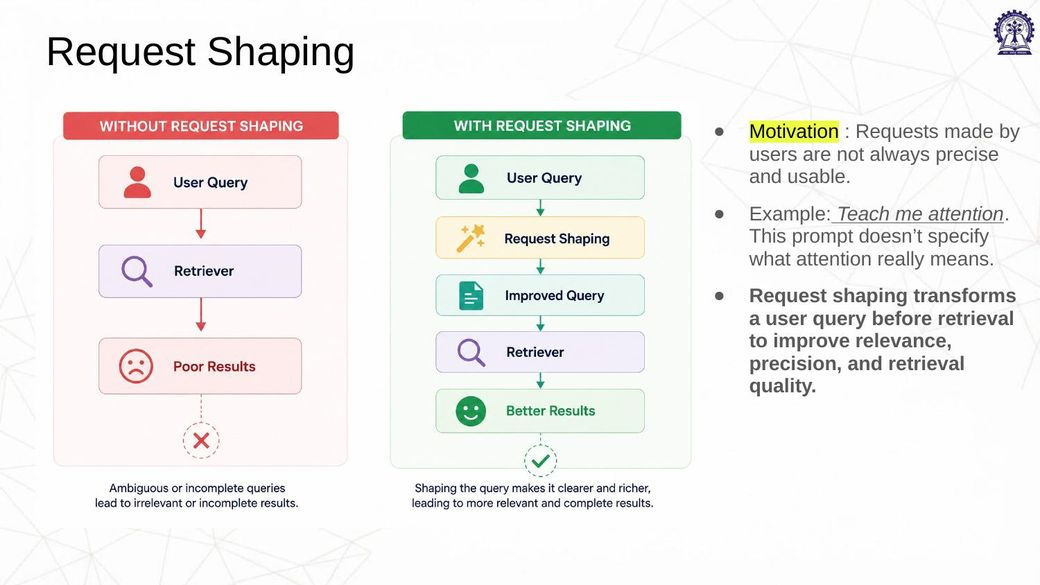

*📊 Reference slide — Request shaping reshapes a vague request before it ever hits retrieval (lecture slide 39).*

In [ ]:
# --- Cell 1.1 · The request shaper ---
def shape_request(raw_query):
    prompt = (
        "Rewrite the short IT/HR support request into ONE precise, searchable sentence providing enough context for better retrieval. "
        "Keep it specific and self-contained.\n"
        f"Request: \"{raw_query}\"\n"
        "Precise version:"
    )
    return llm(prompt, max_new_tokens=16)

# Examples taken straight from slide 41:
for q in ["Server down.", "Car leasing policy", "Latest bugs assigned"]:
    print(f"RAW : {q}\nSHAPED: {shape_request(q)}\n")

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
[transformers] Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


RAW : Server down.
SHAPED: **Server outage reported; immediate investigation required.**<turn|>



[transformers] Both `max_new_tokens` (=16) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


RAW : Car leasing policy
SHAPED: **Please provide the current car leasing policy document.**<turn|>

RAW : Latest bugs assigned
SHAPED: **Please provide a list of the latest bugs assigned to me.**<turn|>



**What just happened (production view):** a noisy Slack message becomes a clean query.
Better input → better retrieval → fewer hallucinations. Shaping is cheap insurance applied to
*every* request. Next we look at *targeted* transformations for specific situations.

---
# 2 · Query Transformations  *(Slides 44–47)*

Four targeted techniques. Each one fixes a specific retrieval failure mode.

### 2.1 · Rewriting  *(Slide 44)*
Turn cryptic jargon / error codes into a clear search statement.
**Production trigger:** support channels where people paste `OOMKilled` instead of a sentence.

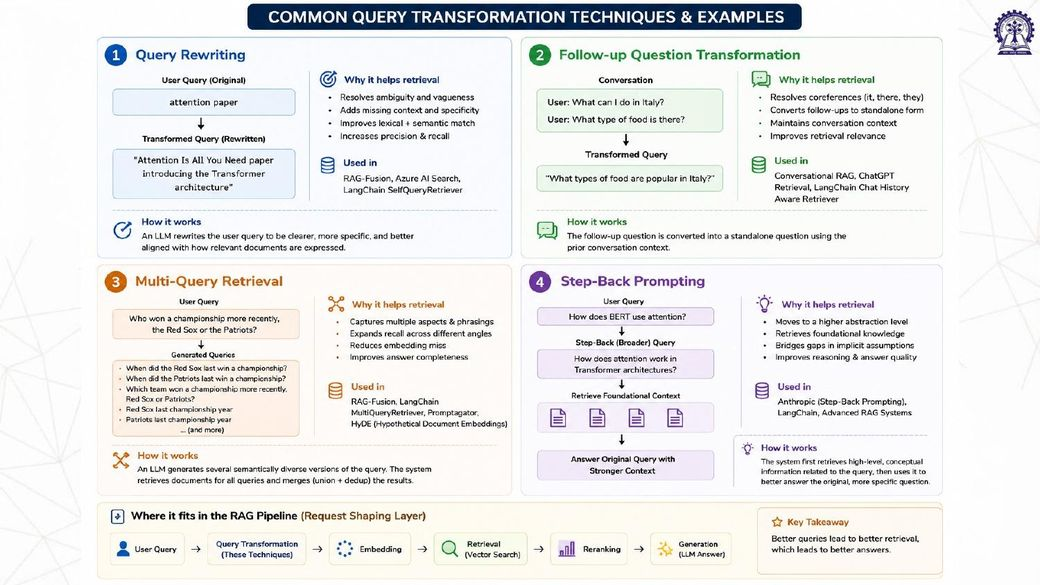

*📊 Reference slide — The four query-transformation techniques at a glance — rewrite, follow-up, multi-query, step-back (lecture slides 44–47).*

In [ ]:
# --- Cell 2.1 · Query rewriting ---
def rewrite_query(q):
    prompt = ("A user typed a short error or jargon. Rewrite it as a clear technical question "
              "for searching internal runbooks. Be precise!\n"
              f"Input: \"{q}\"\nClear question:")
    return llm(prompt, max_new_tokens=128)

raw = "OOMKilled"
rewritten = rewrite_query(raw)
print("ORIGINAL  :", raw)
print("REWRITTEN :", rewritten)
print("\nRetrieval with the rewritten query:")
for h in CODE_DB.search(rewritten, k=2):
    print(f"  {h['score']:.2f}  {h['meta']['source']}")

[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ORIGINAL  : OOMKilled
REWRITTEN : **What is the cause of the OOMKilled error, and what are the recommended steps to prevent Out-Of-Memory (OOM) conditions in this process?**<turn|>

Retrieval with the rewritten query:
  0.51  runbooks/oomkilled.md
  0.20  runbooks/cicd_pipeline.md


### 2.2 · Follow-up → Standalone  *(Slide 45)*
Multi-turn chats use pronouns (*"Does **it** apply to contractors?"*). The retriever needs a
**self-contained** query. We inject the conversation history and condense.

In [ ]:
# --- Cell 2.2 · Condense a follow-up into a standalone query ---
def condense_followup(history, followup):
    convo = "\n".join(f"{r}: {t}" for r, t in history)
    prompt = ("Given the conversation, rewrite the final user question as a standalone question "
              "that needs no prior context.\n"
              f"{convo}\nUser: {followup}\nStandalone question:")
    return llm(prompt, max_new_tokens=48)

history = [("User", "What is the standard parental leave policy?"),
           ("Agent", "Full-time employees get 26 weeks of paid parental leave.")]
standalone = condense_followup(history, "Does it apply to contractors?")
print("FOLLOW-UP :", "Does it apply to contractors?")
print("STANDALONE:", standalone)
print("\nRetrieval with the standalone query:")
for h in HR_DB.search(standalone, k=1):
    print(f"  {h['score']:.2f}  {h['meta']['source']}")

[transformers] Both `max_new_tokens` (=48) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


FOLLOW-UP : Does it apply to contractors?
STANDALONE: Does the standard parental leave policy apply to contractors?<turn|>

Retrieval with the standalone query:
  0.82  hr/parental_leave.md


### 2.3 · Multi-Query Retrieval  *(Slide 46)*
A question that spans **two entities** (Mumbai *and* US-East) should be split into parallel
sub-queries so each entity gets dedicated, un-diluted retrieval.

In [ ]:
# --- Cell 2.3 · Multi-query expansion ---
def multi_query(q, n=2):
    prompt = ("Split this question into separate, focused sub-questions (one per entity/region). "
              "List them on separate lines.\n"
              f"Question: {q}\nSub-questions:")
    out = llm(prompt, max_new_tokens=96)
    subs = [s.strip(" -•0123456789.") for s in out.splitlines() if s.strip()]
    # Robust fallback: if the small model returns one line, derive sub-queries from detected entities
    if len(subs) < 2:
        for region in ["Mumbai", "US-East"]:
            if region.lower() in q.lower():
                subs.append(f"latency metrics and error logs for the {region} deployment")
    return subs[:max(n, len(subs))]

q = "Did the latency spike happen in both the Mumbai and US-East Vertex AI deployments?"
for sub in multi_query(q):
    print("•", sub, "->", get_live_logs("mumbai" if "mumbai" in sub.lower() else "us-east")[0])

[transformers] Both `max_new_tokens` (=96) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


• Did the latency spike happen in the Mumbai Vertex AI deployment? -> 12:02:00 region mumbai: vertex-ai latency spike p99 980ms (degraded)
• Did the latency spike happen in the US-East Vertex AI deployment?<turn|> -> 12:02:00 region us-east: all services healthy, p99 latency 120ms


### 2.4 · Step-Back Prompting  *(Slide 47)*
When a question is too "in the weeds", first ask a **broader** question to pull foundational context.
Here the broad query surfaces the architectural rule that *rogue units have no switch data* — which
explains the user's empty results instead of hallucinating.

In [ ]:
# --- Cell 2.4 · Step-back prompting ---
def step_back(q):
    prompt = ("Write a broader, higher-level background question whose answer gives the foundational "
              "context needed to address the specific question.\n"
              f"Specific question: {q}\nBroader question:")
    return llm(prompt, max_new_tokens=48)

specific = "Why can't I pull the switch association data for the rogue units on Floor 3?"
broad = step_back(specific)
print("SPECIFIC:", specific)
print("STEP-BACK:", broad)
print("\nFoundational context retrieved by the step-back query:")
for h in CODE_DB.search(broad + " rogue units reporting access points switch data", k=1):
    print(f"  {h['score']:.2f}  {h['meta']['source']}\n  -> {h['text']}")

[transformers] Both `max_new_tokens` (=48) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


SPECIFIC: Why can't I pull the switch association data for the rogue units on Floor 3?
STEP-BACK: Here are several options for a broader, higher-level background question, depending on the likely context of the specific question. Choose the one that best fits the domain you are working in:

**Option 1 (Focus on System Architecture/

Foundational context retrieved by the step-back query:
  0.62  runbooks/network_arch.md
  -> Network architecture: switch-association data is collected ONLY for reporting access points, never for rogue units. Queries about rogue-unit switch data will always be empty.


---
# 3 · Query Routing  *(Slides 49–62)*

We now have transformed queries — but **which** knowledge source / model / index should handle each one?
Hardcoding `if/else` everywhere is brittle. **Query routing** is the intelligent traffic cop that
sends each request to the optimal destination, maximising accuracy while cutting latency and cost.

We implement all five strategies from slide 53, then the three *applications* (slides 59–62).
Our routing targets: **`HR_DB`**, **`CODE_DB`**, **`LIVE_LOGS`**.

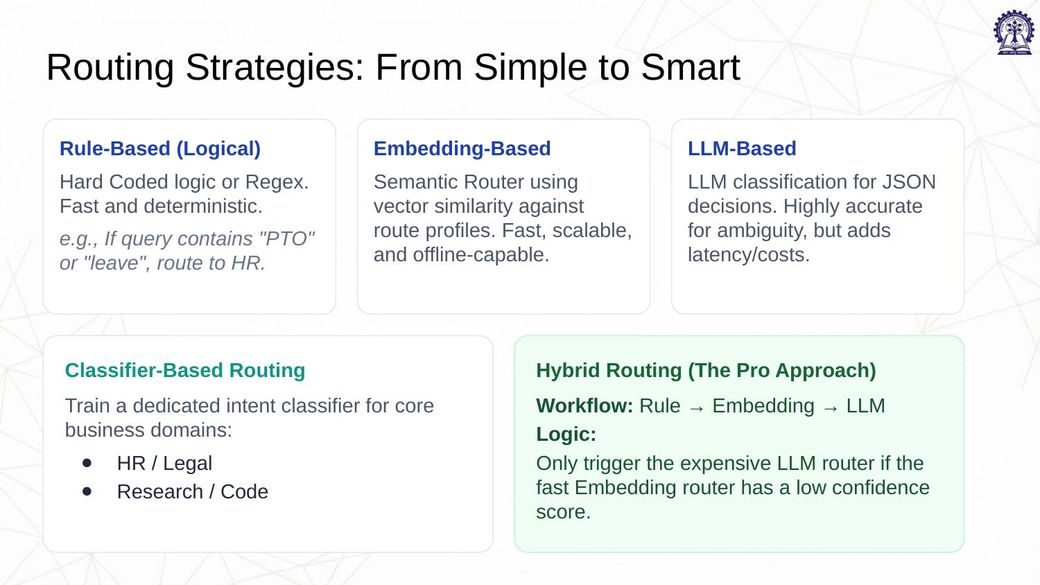

*📊 Reference slide — Routing strategies, from simple-and-brittle to smart-and-costly (lecture slide 53).*

### 3.1 · Rule-Based Routing  *(Slide 54)*
Regex/keyword logic. **$0.00, ~1 ms, deterministic** — but brittle: it misses paraphrases.
We deliberately show the failure case from the slide (*"I need to take time off"*).

In [ ]:
# --- Cell 3.1 · Rule-based router ---
RULES = [
    (r"\b(pto|leave|payroll|salary|compensation|benefit|parental|maternity|car.?leas|manager)\b", "HR_DB"),
    (r"\b(oom|oomkilled|kubernetes|k8s|container|auth|token|pipeline|commit|deploy|module|bug|pr|code)\b", "CODE_DB"),
    (r"\b(down|crash|crashed|latency|spike|incident|outage|logs?)\b", "LIVE_LOGS"),
]
def rule_router(query):
    ql = query.lower()
    for pat, route in RULES:
        if re.search(pat, ql):
            return route
    return None        # None == "I don't know", hand off to a smarter router

print("'How many days of leave do I have left?' ->", rule_router("How many days of leave do I have left?"))
print("'I need to take time off'                ->", rule_router("I need to take time off"), "  ❌ keyword miss")

'How many days of leave do I have left?' -> HR_DB
'I need to take time off'                -> None   ❌ keyword miss


### 3.2 · Embedding-Based Routing  *(Slide 55)*
Build a **profile** (sample questions) per destination, average them into a centroid, then route by
cosine similarity. Fast, offline, and understands **meaning** — so it catches *"I need to take time off"*.

In [ ]:
# --- Cell 3.2 · Embedding (semantic) router ---
ROUTE_PROFILES = {
    "HR_DB": ["how many vacation days do I have", "parental leave policy", "car leasing benefit",
              "I need to take time off", "I am burnt out and need a break", "payroll question"],
    "CODE_DB": ["why does my container get OOMKilled", "auth token expiry bug", "how to fix the CI pipeline",
                "review this pull request", "kubernetes deployment runbook"],
    "LIVE_LOGS": ["is us-east down right now", "the payment service just crashed", "current latency spike",
                  "show me logs from the last 5 minutes", "active incident report"],
}
ROUTE_CENTROIDS = {r: embed(s).mean(0) for r, s in ROUTE_PROFILES.items()}
ROUTE_CENTROIDS = {r: c / np.linalg.norm(c) for r, c in ROUTE_CENTROIDS.items()}

def embedding_router(query):
    qv = embed(query)
    scored = {r: float(qv @ c) for r, c in ROUTE_CENTROIDS.items()}
    best = max(scored, key=scored.get)
    return best, scored[best], scored

route, conf, all_scores = embedding_router("I need to take time off")
print("Query: 'I need to take time off'")
print("Route:", route, f"(confidence {conf:.2f})  ✅ caught by meaning")
print("All scores:", {k: round(v, 2) for k, v in all_scores.items()})

Query: 'I need to take time off'
Route: HR_DB (confidence 0.59)  ✅ caught by meaning
All scores: {'HR_DB': 0.59, 'CODE_DB': 0.05, 'LIVE_LOGS': 0.22}


### 3.3 · Classifier-Based Routing  *(Slide 56)*
Train a **lightweight ML model** on historical (query → label) pairs. Outputs calibrated probabilities,
runs in microseconds, and improves as you collect more labelled traffic.

In [ ]:
# --- Cell 3.3 · Classifier-based router (TF-IDF + Logistic Regression) ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

TRAIN = [(q, lbl) for lbl, qs in ROUTE_PROFILES.items() for q in qs] + [
    ("my compensation seems wrong this month", "HR_DB"),
    ("token expires too fast is it a bug", "CODE_DB"),
    ("the region is unreachable", "LIVE_LOGS"),
]
X, y = zip(*TRAIN)
clf = make_pipeline(TfidfVectorizer(ngram_range=(1, 2)), LogisticRegression(max_iter=1000))
clf.fit(X, y)

def classifier_router(query):
    probs = clf.predict_proba([query])[0]
    labels = clf.classes_
    i = int(np.argmax(probs))
    return labels[i], float(probs[i])

label, p = classifier_router("My compensation seems wrong this month.")
print(f"Query routed to {label} (confidence {p:.0%})")

Query routed to HR_DB (confidence 53%)


### 3.4 · LLM-Based Routing  *(Slide 57)*
For genuinely ambiguous queries, ask the LLM to reason and pick a route. Most accurate on hard cases,
but it costs latency + tokens — so we reserve it for when cheaper routers are unsure.

In [ ]:
# --- Cell 3.4 · LLM-based router ---
def llm_router(query):
    prompt = ("Route the query to ONE database. Reply with only the label.\n"
              "HR_DB = people, pay, leave, benefits.\n"
              "CODE_DB = source code, bugs, infra runbooks.\n"
              "LIVE_LOGS = real-time outages, crashes, current logs.\n"
              f"Query: \"{query}\"\nLabel:")
    out = llm(prompt, max_new_tokens=8).upper()
    for r in ["HR_DB", "CODE_DB", "LIVE_LOGS"]:
        if r.replace("_", "") in out.replace("_", "").replace(" ", ""):
            return r
    return "CODE_DB"   # safe default

q = "The auth token is expiring too fast. Is this a new security policy thing or a bug?"
print("Query:", q, "\nLLM route ->", llm_router(q))

[transformers] Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Query: The auth token is expiring too fast. Is this a new security policy thing or a bug? 
LLM route -> CODE_DB


### 3.5 · Hybrid Routing — the pro approach  *(Slide 58)*
A **waterfall**: try the cheap router first; only escalate to the expensive one on **low confidence**.
This is what real systems run — you pay for the LLM **only when you must**.

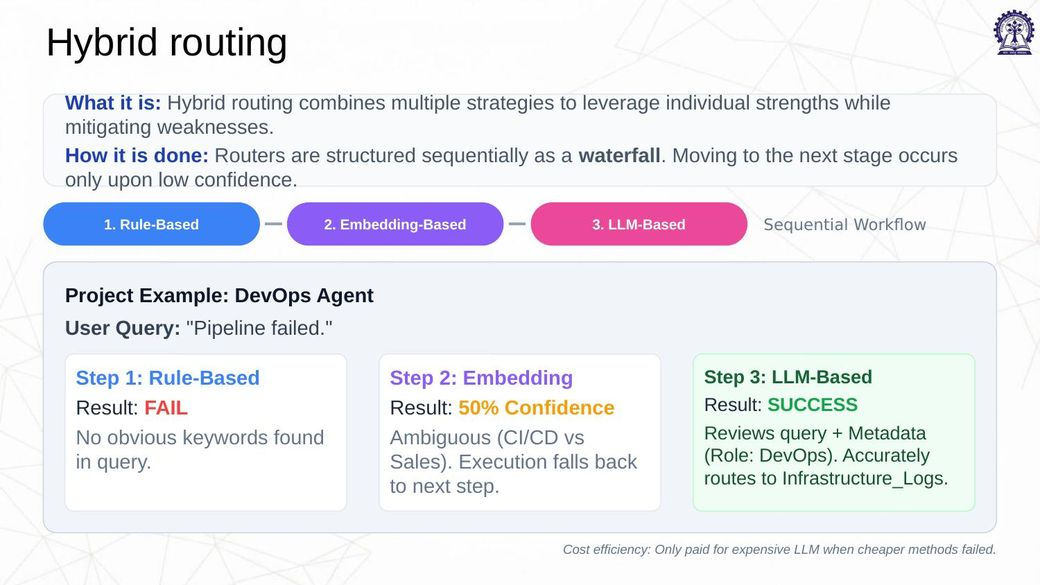

*📊 Reference slide — Hybrid routing as a cost-aware waterfall: escalate only on low confidence (lecture slide 58).*

In [ ]:
# --- Cell 3.5 · Hybrid waterfall router ---
EMB_CONF_THRESHOLD = 0.45   # below this, the embedding router is "unsure"

def hybrid_router(query, verbose=True):
    # Stage 1: rules (free)
    r = rule_router(query)
    if r:
        if verbose: print(f"  Stage1 rule    -> {r}")
        return r, "rule"
    # Stage 2: embeddings (cheap)
    r, conf, _ = embedding_router(query)
    if verbose: print(f"  Stage2 embed   -> {r} (conf {conf:.2f})")
    if conf >= EMB_CONF_THRESHOLD:
        return r, "embedding"
    # Stage 3: LLM (expensive, only if unsure)
    r = llm_router(query)
    if verbose: print(f"  Stage3 LLM     -> {r} (escalated, low confidence)")
    return r, "llm"

print("Query: 'Pipeline failed.'")
route, who = hybrid_router("Pipeline failed.")
print(f"FINAL ROUTE: {route}  (decided by: {who})")

Query: 'Pipeline failed.'
  Stage1 rule    -> CODE_DB
FINAL ROUTE: CODE_DB  (decided by: rule)


### 3.6 · The three Applications of routing  *(Slides 59–62)*
Routing isn't only about **which database**. It also chooses **which model** (cost vs quality) and
**how** to search/prompt (index & prompt routing).

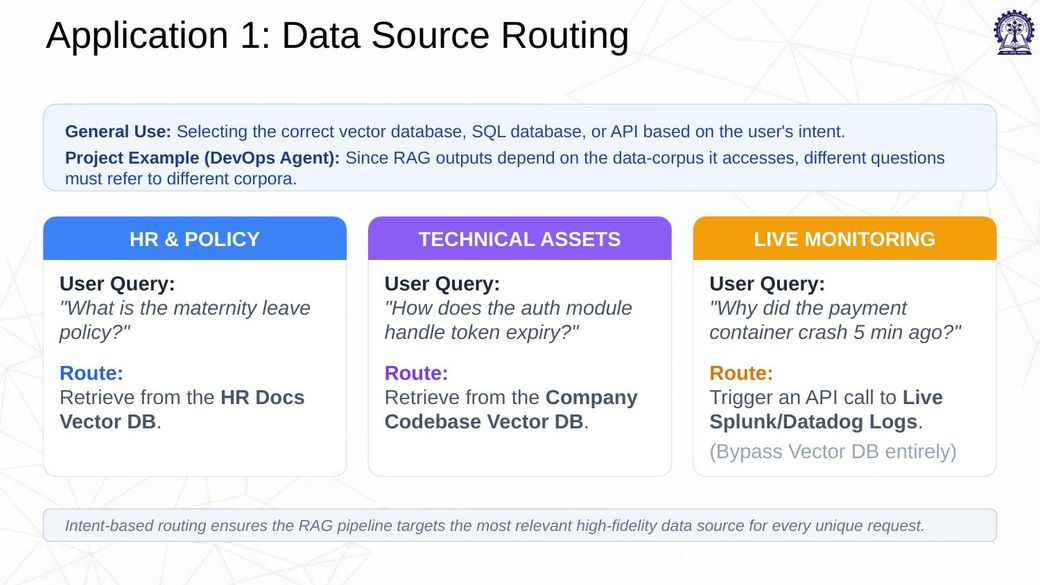

*📊 Reference slide — Application 1 — data-source routing across HR, code, and live logs (lecture slide 59).*

In [ ]:
# --- Cell 3.6 · Application 2 (Model/Workflow) & Application 3 (Index/Prompt) ---

def model_workflow_router(query):
    """App 2: cheap model for simple extraction, premium workflow for complex reasoning."""
    simple_markers = ["format", "convert", "extract", "list", "json"]
    if any(m in query.lower() for m in simple_markers) and len(query.split()) < 25:
        return {"model": "small-cheap (e.g. flan-t5/Haiku)", "workflow": "single-shot"}
    return {"model": "premium-reasoning (e.g. GPT-4/Opus)", "workflow": "multi-step agentic"}

def index_prompt_router(query):
    """App 3: keyword/sparse index for exact codes; summarise-prompt for aggregation."""
    if re.search(r"\b(error code|code\s+\d+|exact|exception|\bE\d{3,}\b)\b", query.lower()):
        return {"index": "Sparse / BM25 (exact match)", "prompt": "extraction"}
    if any(w in query.lower() for w in ["summar", "overview", "changes", "last quarter"]):
        return {"index": "Dense / vector", "prompt": "summarization template"}
    return {"index": "Dense / vector", "prompt": "default QA"}

print("App2:", model_workflow_router("Format this server log into a JSON block."))
print("App2:", model_workflow_router("Review this 500-line PR against our security guidelines and summarise."))
print("App3:", index_prompt_router("Find the specific error code in the network manual."))
print("App3:", index_prompt_router("Summarize the architectural changes made to the database last quarter."))

App2: {'model': 'small-cheap (e.g. flan-t5/Haiku)', 'workflow': 'single-shot'}
App2: {'model': 'premium-reasoning (e.g. GPT-4/Opus)', 'workflow': 'multi-step agentic'}
App3: {'index': 'Sparse / BM25 (exact match)', 'prompt': 'extraction'}
App3: {'index': 'Dense / vector', 'prompt': 'summarization template'}


---
# 4 · Retrieval Gateways — the "Enterprise Bouncer"  *(Slides 63–71)*

The router now picks the right destination — but before we actually touch private company data we must
pass through a **gateway** that enforces four production concerns:

1. **Access Control (RBAC)** — never leak data a user isn't allowed to see *(slide 66)*
2. **Cost Management (FinOps)** — never let a runaway loop burn the cloud budget *(slide 68)*
3. **Semantic Caching** — never pay twice for the same question *(slides 69–70)*
4. **Observability** — log everything so you can trace any answer *(slide 71)*

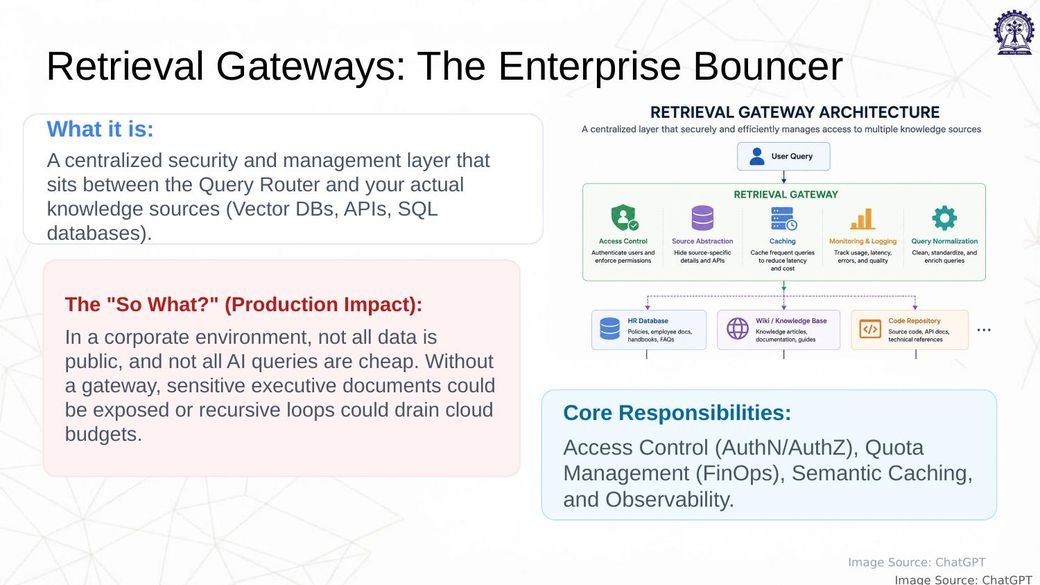

*📊 Reference slide — The retrieval gateway: the enterprise 'bouncer' between routing and your data (lecture slide 65).*

### 4.1 · Access Control / RBAC  *(Slide 66)*
The gateway reads the user's **role**, derives the **sensitivity labels** they may read, and passes that
as a metadata filter to the vector store. A junior engineer asking for salary bands gets **zero docs**;
the HR director gets the confidential chunk.

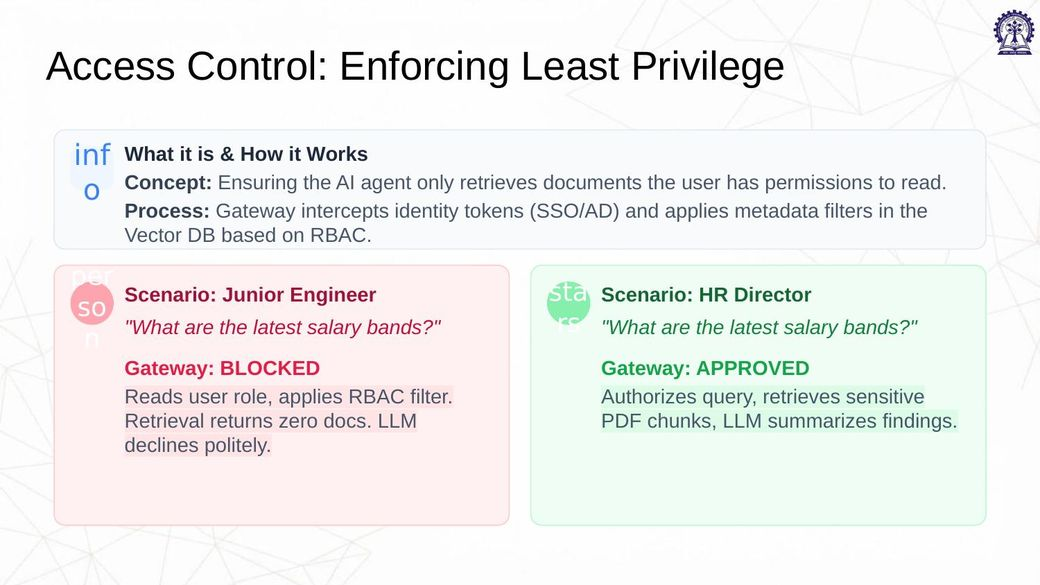

*📊 Reference slide — Access control — the same query returns different results depending on the caller's role (lecture slide 66).*

In [ ]:
# --- Cell 4.1 · Role-based access control ---
ROLE_PERMISSIONS = {
    "junior_engineer": {"public", "code"},
    "devops":          {"public", "code"},
    "hr_director":     {"public", "code", "hr_confidential"},
}
def allowed_for(role):
    return ROLE_PERMISSIONS.get(role, {"public"})

q = "What are the latest salary bands?"
for role in ["junior_engineer", "hr_director"]:
    hits = HR_DB.search(q, k=3, allowed_sensitivity=allowed_for(role))
    sources = [h["meta"]["source"] for h in hits]
    verdict = "APPROVED ✅" if any(h["meta"]["sensitivity"] == "hr_confidential" for h in hits) else "BLOCKED 🔒"
    print(f"{role:15s} -> {verdict}  docs={sources}")

junior_engineer -> BLOCKED 🔒  docs=['hr/pto_policy.md', 'hr/parental_leave.md', 'hr/car_leasing.md']
hr_director     -> APPROVED ✅  docs=['hr/salary_bands.md', 'hr/pto_policy.md', 'hr/parental_leave.md']


### 4.2 · Cost Management  *(Slide 68)*
Track token spend per user/team; enforce a cap; **throttle** or **downgrade to a cheaper model** at 90%
budget. This is the guardrail that prevents the *"recursive bug burns \$30k"* scenario from the slide.

In [ ]:
# --- Cell 4.2 · Cost manager ---
class CostManager:
    def __init__(self, monthly_token_cap=50_000):
        self.cap, self.used = monthly_token_cap, 0
    def pick_model(self):
        return "cheaper-local-model" if self.used >= 0.9 * self.cap else "premium-model"
    def charge(self, tokens):
        self.used += tokens
        return self.used <= self.cap          # False == over budget, request should be throttled
    def report(self):
        return f"{self.used:,}/{self.cap:,} tokens ({self.used/self.cap:.0%})"

cm = CostManager(monthly_token_cap=10_000)
for i in range(1, 6):
    ok = cm.charge(2_500)
    print(f"call {i}: model={cm.pick_model():22s} spend={cm.report()} {'' if ok else '⛔ THROTTLED'}")

call 1: model=premium-model          spend=2,500/10,000 tokens (25%) 
call 2: model=premium-model          spend=5,000/10,000 tokens (50%) 
call 3: model=premium-model          spend=7,500/10,000 tokens (75%) 
call 4: model=cheaper-local-model    spend=10,000/10,000 tokens (100%) 
call 5: model=cheaper-local-model    spend=12,500/10,000 tokens (125%) ⛔ THROTTLED


### 4.3 · Semantic Caching  *(Slides 69–70)*
Store `(query_embedding → answer)`. A new query that **means the same thing** (cosine ≥ τ) is served from
cache in milliseconds. The slide's key insight: **a false hit is far costlier than a miss**, so set τ
**high**. Below we show the 200-engineers-ask-the-same-thing scenario.

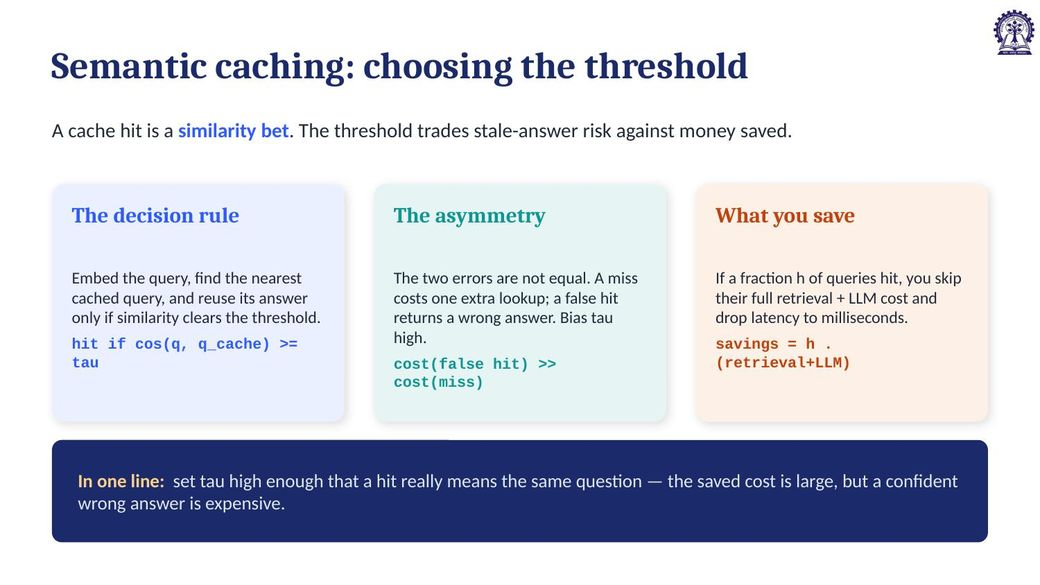

*📊 Reference slide — Semantic caching: why the similarity threshold τ must be set high (lecture slide 70).*

In [ ]:
# --- Cell 4.3 · Semantic cache ---
class SemanticCache:
    def __init__(self, tau=0.90):                # τ high on purpose (slide 70)
        self.tau, self.keys, self.vecs, self.answers = tau, [], None, []
        self.hits, self.misses = 0, 0
    def get(self, query):
        if self.vecs is None:
            self.misses += 1; return None
        sims = self.vecs @ embed(query)
        i = int(np.argmax(sims))
        if sims[i] >= self.tau:
            self.hits += 1
            return {"answer": self.answers[i], "matched": self.keys[i], "sim": float(sims[i])}
        self.misses += 1; return None
    def put(self, query, answer):
        v = embed(query)[None, :]
        self.vecs = v if self.vecs is None else np.vstack([self.vecs, v])
        self.keys.append(query); self.answers.append(answer)

cache = SemanticCache(tau=0.85)
variants = ["Is US-East down?", "Is the US-East region down?", "us-east outage?", "Is US East currently down right now?"]
first = cache.get(variants[0]) or cache.put(variants[0], "US-East is healthy, p99 120ms.")
print(f"'{variants[0]}' -> computed & cached")
for v in variants[1:]:
    r = cache.get(v)
    print(f"'{v}' -> {'CACHE HIT (sim %.2f)' % r['sim'] if r else 'miss (recompute)'}")
print(f"\nCache stats: {cache.hits} hits / {cache.misses} misses  → 199 such hits would skip 199 LLM calls")

'Is US-East down?' -> computed & cached
'Is the US-East region down?' -> CACHE HIT (sim 0.89)
'us-east outage?' -> miss (recompute)
'Is US East currently down right now?' -> CACHE HIT (sim 0.87)

Cache stats: 2 hits / 2 misses  → 199 such hits would skip 199 LLM calls


### 4.4 · Observability + the unified Gateway  *(Slide 71)*
Finally we wire RBAC + cost + cache + logging into **one** `RetrievalGateway`. Every call is logged with
a query-id so the platform team can later trace *exactly* which chunk produced a bad answer.

In [ ]:
# --- Cell 4.4 · The unified Retrieval Gateway ---
class RetrievalGateway:
    def __init__(self):
        self.cache = SemanticCache(tau=0.85)
        self.cost  = CostManager(monthly_token_cap=100_000)
        self.log   = []
        self.stores = {"HR_DB": HR_DB, "CODE_DB": CODE_DB}

    def retrieve(self, query, route, role, k=3):
        qid = f"q{len(self.log)+1:04d}"
        # 1) cache
        cached = self.cache.get(query)
        if cached:
            self._log(qid, query, route, role, "CACHE_HIT", cached["sim"]); return cached["answer"], qid
        # 2) live logs bypass the vector DB entirely (slide 59)
        if route == "LIVE_LOGS":
            svc = "payment" if "payment" in query.lower() else ("mumbai" if "mumbai" in query.lower() else "us-east")
            docs = [{"text": l, "meta": {"source": f"live/{svc}", "sensitivity": "code"}} for l in get_live_logs(svc)]
        else:
            store = self.stores.get(route, CODE_DB)
            docs = store.search(query, k=k, allowed_sensitivity=allowed_for(role))
        # 3) cost accounting
        self.cost.charge(tokens=200)
        self._log(qid, query, route, role, "RETRIEVED", n=len(docs))
        self.cache.put(query, docs)
        return docs, qid

    def _log(self, qid, query, route, role, status, sim=None, n=None):
        self.log.append({"qid": qid, "query": query[:40], "route": route, "role": role,
                         "status": status, "sim": sim, "n_docs": n, "spend": self.cost.used})

gw = RetrievalGateway()
gw.retrieve("What are the latest salary bands?", "HR_DB", "hr_director")
gw.retrieve("What are the latest salary bands?", "HR_DB", "junior_engineer")
gw.retrieve("Why did the payment container crash?", "LIVE_LOGS", "devops")
import pandas as pd
pd.DataFrame(gw.log)

,qid,query,route,role,status,sim,n_docs,spend
0,q0001,What are the latest salary bands?,HR_DB,hr_director,RETRIEVED,NaN,3.0,200
1,q0002,What are the latest salary bands?,HR_DB,junior_engineer,CACHE_HIT,1.0,NaN,200
2,q0003,Why did the payment container crash?,LIVE_LOGS,devops,RETRIEVED,NaN,3.0,400


---
# 5 · Agentic Orchestration  *(Slides 72–75)*

Single-shot RAG assumes one search finds everything. Real incidents are **multi-hop**: search → read →
realise something's missing → search again. We can't `if/else` our way through every path, so we hand the
*how* to the LLM, structured as a **state machine** (the LangGraph pattern).

**Capstone task (slide 73):**
> *"Find the error in the payment container, check if it's related to yesterday's auth module commit,
> and if so, draft a Slack update for the QA team."*

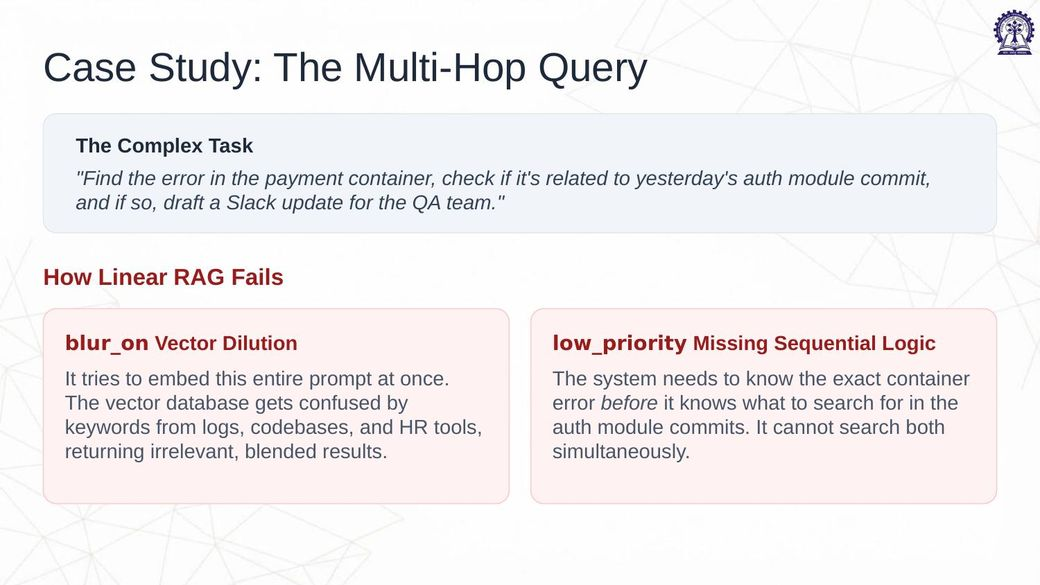

*📊 Reference slide — The multi-hop case study that drives the capstone agent (lecture slide 73).*

### 5.1 · Why single-shot fails (vector dilution)  *(Slides 72–73)*
Embedding the whole multi-part prompt blends keywords from logs + code + HR and returns muddy results.

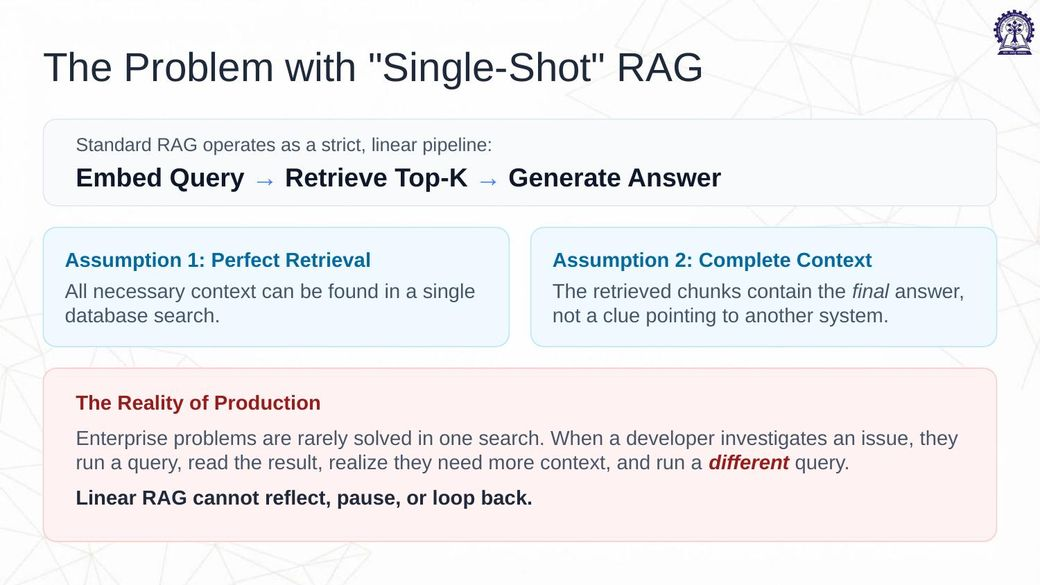

*📊 Reference slide — Why single-shot RAG breaks on real, multi-step incidents (lecture slide 72).*

In [ ]:
# --- Cell 5.1 · Demonstrate vector dilution ---
multihop = ("Find the error in the payment container, check if it is related to yesterday's auth "
            "module commit, and draft a Slack update for the QA team.")
print("Single-shot retrieval on the full prompt (note the mixed, unfocused hits):")
for h in CODE_DB.search(multihop, k=3):
    print(f"  {h['score']:.2f}  {h['meta']['source']}")

Single-shot retrieval on the full prompt (note the mixed, unfocused hits):
  0.50  runbooks/payment_service.md
  0.33  runbooks/cicd_pipeline.md
  0.31  runbooks/auth_token.md


### 5.2 · Tools + Planner vs Executor  *(Slide 75)*
- **Executor** = the hands: a fixed set of reliable *tools* (search logs, search code, draft Slack).
- **Planner** = the brain: decides the *next* tool based on the current state.

Separating them keeps tools deterministic while the LLM only makes small, checkable decisions.

In [ ]:
# --- Cell 5.2 · Tools (executor side) ---
def tool_get_payment_logs(state):
    state["logs"] = get_live_logs("payment")
    state["error_found"] = any("error" in l.lower() or "137" in l for l in state["logs"])
    state["mentions_auth"] = any("auth" in l.lower() for l in state["logs"])
    return state

def tool_search_auth_code(state):
    hits = CODE_DB.search("auth module token refresh recent commit AUTH_TTL", k=1,
                          allowed_sensitivity={"public", "code"})
    state["auth_runbook"] = hits[0] if hits else None
    state["auth_logs"] = get_live_logs("auth")
    state["related"] = bool(state.get("mentions_auth")) and any("commit" in l.lower() for l in state["auth_logs"])
    return state

def tool_draft_slack(state):
    err = state["logs"][0]
    commit = next((l for l in state["auth_logs"] if "commit" in l.lower()), "an auth change")
    state["slack"] = (f"[QA UPDATE] Payment container is crash-looping ({err.split('payment-')[-1][:40]}…). "
                      f"Root cause traced to {commit.split('INFO')[-1].strip()}. Rolling back AUTH_TTL. ETA 15m.")
    return state

TOOLS = {"get_payment_logs": tool_get_payment_logs,
         "search_auth_code": tool_search_auth_code,
         "draft_slack": tool_draft_slack}
print("Executor tools registered:", list(TOOLS))

Executor tools registered: ['get_payment_logs', 'search_auth_code', 'draft_slack']


In [ ]:
# --- Cell 5.3 · The state machine (LangGraph-style) ---
class StateGraph:
    """A minimal LangGraph-style engine: nodes mutate a shared state dict; edges (fixed or
    conditional) decide the next node. Identical mental model to LangGraph's StateGraph."""
    def __init__(self):
        self.nodes, self.edges, self.cond, self.entry = {}, {}, {}, None
    def add_node(self, name, fn):       self.nodes[name] = fn
    def add_edge(self, a, b):           self.edges[a] = b
    def add_conditional(self, a, fn):   self.cond[a] = fn
    def set_entry(self, n):             self.entry = n
    def run(self, state, max_steps=12):
        node, steps, trace = self.entry, 0, []
        while node != "END" and steps < max_steps:
            trace.append(node)
            state = self.nodes[node](state)
            steps += 1
            if node in self.cond:   node = self.cond[node](state)
            elif node in self.edges: node = self.edges[node]
            else: node = "END"
        state["trace"] = trace
        return state

# Build the agent graph: logs -> code -> (slack if related else end)
agent = StateGraph()
agent.add_node("get_payment_logs", TOOLS["get_payment_logs"])
agent.add_node("search_auth_code", TOOLS["search_auth_code"])
agent.add_node("draft_slack",      TOOLS["draft_slack"])
agent.add_node("finish",           lambda s: {**s, "done": True})
agent.set_entry("get_payment_logs")
agent.add_edge("get_payment_logs", "search_auth_code")
agent.add_conditional("search_auth_code", lambda s: "draft_slack" if s["related"] else "finish")
agent.add_edge("draft_slack", "finish")
agent.add_edge("finish", "END")
print("Graph built. Entry:", agent.entry)

Graph built. Entry: get_payment_logs


In [ ]:
# --- Cell 5.4 · Run the multi-hop agent ---
result = agent.run({})
print("EXECUTION PATH:", " → ".join(result["trace"]))
print("\nStep 1  logs error found :", result["error_found"], "| mentions auth:", result["mentions_auth"])
print("Step 2  related to commit:", result["related"])
print("\nStep 3  DRAFTED SLACK MESSAGE:\n ", result["slack"])

EXECUTION PATH: get_payment_logs → search_auth_code → draft_slack → finish

Step 1  logs error found : True | mentions auth: True
Step 2  related to commit: True

Step 3  DRAFTED SLACK MESSAGE:
  [QA UPDATE] Payment container is crash-looping (7f9 ERROR exit code 137 OOMKilled after …). Root cause traced to deployed commit a91f2 'reduce AUTH_TTL 900->120s'. Rolling back AUTH_TTL. ETA 15m.


---
# 6 · Context & Memory + Provenance  *(content table)*

Two kinds of memory:
- **Episodic** — the *current* conversation buffer (short-term; powers the follow-up condenser from 2.2).
- **Long-term** — durable facts stored as vectors and recalled across sessions.

Plus **provenance / citations**: every fact in the final answer must point back to the chunk it came from.

In [ ]:
# --- Cell 6.1 · Episodic (buffer) + Long-term (vector) memory ---
class EpisodicMemory:
    def __init__(self, max_turns=6): self.turns, self.max = [], max_turns
    def add(self, role, text): self.turns.append((role, text)); self.turns = self.turns[-self.max:]
    def history(self): return list(self.turns)

class LongTermMemory(VectorStore):
    def remember(self, fact, source="memory"):
        self.add([{"text": fact, "meta": {"source": source, "sensitivity": "public"}}])
    def recall(self, query, k=2):
        return self.search(query, k=k)

episodic = EpisodicMemory()
episodic.add("User", "What is the standard parental leave policy?")
episodic.add("Agent", "26 weeks of paid parental leave for full-time staff.")
print("Episodic buffer:", episodic.history())

ltm = LongTermMemory("LTM")
ltm.remember("The user is a DevOps engineer who owns the payment service.")
ltm.remember("AUTH_TTL was lowered to 120s in commit a91f2 yesterday.")
print("\nLong-term recall for 'who owns payments?':")
for h in ltm.recall("who owns the payment service"):
    print(f"  {h['score']:.2f}  {h['text']}")

Episodic buffer: [('User', 'What is the standard parental leave policy?'), ('Agent', '26 weeks of paid parental leave for full-time staff.')]

Long-term recall for 'who owns payments?':
  0.63  The user is a DevOps engineer who owns the payment service.
  0.15  AUTH_TTL was lowered to 120s in commit a91f2 yesterday.


In [ ]:
# --- Cell 6.2 · Provenance / citations ---
def answer_with_citations(question, hits):
    """Generate an answer from retrieved chunks and append numbered source citations."""
    context = "\n".join(f"[{i+1}] {h['text']}" for i, h in enumerate(hits))
    prompt = (f"Answer the question using ONLY the context. Cite sources like [1], [2].\n"
              f"Context:\n{context}\n\nQuestion: {question}\nAnswer:")
    ans = llm(prompt, max_new_tokens=96)
    cites = "\n".join(f"  [{i+1}] {h['meta']['source']}" for i, h in enumerate(hits))
    return f"{ans}\n\nSources:\n{cites}"

q = "Are contractors eligible for paid parental leave?"
hits = HR_DB.search(q, k=2, allowed_sensitivity={"public"})
print(answer_with_citations(q, hits))

---
# 7 · Putting it all together — the production pipeline

One class chains **every stage**: shape → route (hybrid) → gateway (RBAC + cache + cost + log) →
retrieve → answer with citations. This is the architecture a real DevOps & Support Agent runs.

In [ ]:
# --- Cell 7.1 · The full ProductionRAG pipeline ---
class ProductionRAG:
    def __init__(self):
        self.gateway = RetrievalGateway()
        self.episodic = EpisodicMemory()

    def ask(self, raw_query, role="devops"):
        print(f"\n{'='*70}\nUSER ({role}): {raw_query}")
        # 1) Request shaping
        shaped = shape_request(raw_query)
        print(f"1 · shaped     : {shaped}")
        # 2) Follow-up condensing ONLY when the query looks like a real follow-up
        is_followup = self.episodic.history() and re.search(r"\b(it|they|that|this|those|them)\b", raw_query.lower())
        if is_followup:
            shaped = condense_followup(self.episodic.history(), shaped)
            print(f"  · standalone : {shaped}")
        # 3) Hybrid routing
        route, who = hybrid_router(shaped, verbose=False)
        print(f"2 · route      : {route}  (via {who})")
        # 4) Gateway retrieve (RBAC + cache + cost + observability)
        docs, qid = self.gateway.retrieve(shaped, route, role, k=2)
        if isinstance(docs, list) and docs and isinstance(docs[0], dict):
            print(f"3 · retrieved  : {[d['meta']['source'] for d in docs]}  (qid {qid})")
            answer = answer_with_citations(shaped, docs)
        else:
            answer = f"(served from cache, qid {qid})"
        # 5) Update episodic memory
        self.episodic.add("User", raw_query)
        self.episodic.add("Agent", answer.split(chr(10))[0])
        print(f"4 · ANSWER     :\n{answer}")
        return answer

bot = ProductionRAG()
bot.ask("Car leasing policy", role="devops")
bot.ask("What are the latest salary bands?", role="junior_engineer")   # RBAC blocks the confidential doc

# A genuine multi-turn follow-up (note the pronoun 'it' gets resolved):
bot2 = ProductionRAG()
bot2.ask("What is the parental leave policy?", role="devops")
bot2.ask("Does it apply to contractors?", role="devops")              # 'it' -> parental leave policy

---
## ✅ Recap — slide → cell map

| Slides | Topic | Where in this notebook |
|--------|-------|------------------------|
| 39–41 | Request Shaping | §1 |
| 44 | Query Rewriting | §2.1 |
| 45 | Follow-up → Standalone | §2.2 |
| 46 | Multi-Query | §2.3 |
| 47 | Step-Back | §2.4 |
| 54 | Rule-based routing | §3.1 |
| 55 | Embedding routing | §3.2 |
| 56 | Classifier routing | §3.3 |
| 57 | LLM routing | §3.4 |
| 58 | Hybrid routing | §3.5 |
| 59–62 | Routing applications | §3.6 |
| 66 | Access control (RBAC) | §4.1 |
| 68 | Cost management | §4.2 |
| 69–70 | Semantic caching | §4.3 |
| 71 | Observability + Gateway | §4.4 |
| 72–75 | Agentic orchestration (planner/executor, state machine) | §5 |
| memory | Episodic / long-term + citations | §6 |
| capstone | Full production pipeline | §7 |

### Where to go next (production hardening)
- Swap the NumPy store for **FAISS / pgvector / Chroma**; keep the `search()` signature.
- Replace `flan-t5-base` with a hosted model behind the same `llm()` wrapper.
- Move the cache to **Redis**, the logs to **Datadog/Splunk**, and express the state machine in real **LangGraph**.
- Add **evaluation** (LLM-as-judge / retrieval hit-rate) before shipping.